# Electricity Rate Impact — Data Centers & Residential Customers

Four case study regions where major data center buildouts are documented:

| Region | Primary Utility | Boom cutpoint | Rationale |
|---|---|---|---|
| Virginia (VA) | Dominion Energy | 2018 | Loudoun Co. zoning fast-track; DC density surges |
| Arizona (AZ) | APS + SRP | 2020 | Post-COVID hyperscale buildout begins |
| Ohio (OH) | AEP Ohio | 2020 | DC load climbs ~100 MW → 600 MW by 2024 |
| Oregon (OR) | Portland General Electric | 2022 | PGE rate spiral: +7%, +18%, +5.5% successive years |

**Data sources:** EIA `avgprice_annual.xlsx` (annual state-level rates 2001–present), EIA API v2 (monthly residential prices, annual retail sales).

In [ ]:
import sys
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

RAW_DIR  = Path('../data/electricity/raw')
PROC_DIR = Path('../data/electricity/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

EIA_API_KEY = ''   # free key at https://www.eia.gov/opendata/register.php

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

STATE_LABEL = {'VA': 'Virginia', 'AZ': 'Arizona', 'OH': 'Ohio', 'OR': 'Oregon'}
STATE_ABBR  = {'Virginia': 'VA', 'Arizona': 'AZ', 'Ohio': 'OH', 'Oregon': 'OR'}
COLORS      = {'VA': '#1f77b4', 'AZ': '#d62728', 'OH': '#2ca02c', 'OR': '#9467bd'}
BOOM        = {'VA': 2018, 'AZ': 2020, 'OH': 2020, 'OR': 2022}

## Part 1 — Data
### 1.1 Collect raw files

Downloads source data from EIA into `data/electricity/raw/`. Each function skips the download if the file already exists, so re-running is safe.

In [27]:
def eia_get(url):
    """GET an EIA API v2 URL without letting requests encode the brackets."""
    session = requests.Session()
    prepped = requests.Request('GET', url).prepare()
    prepped.url = url
    resp = session.send(prepped, timeout=30)
    if not resp.ok:
        print(f'  EIA error {resp.status_code}: {resp.text[:200]}', file=sys.stderr)
        resp.raise_for_status()
    return resp.json()


def fetch_avgprice():
    local = RAW_DIR / 'avgprice_annual.xlsx'
    if not local.exists():
        print('Downloading avgprice_annual.xlsx ...')
        r = requests.get('https://www.eia.gov/electricity/data/state/avgprice_annual.xlsx', timeout=30)
        r.raise_for_status()
        local.write_bytes(r.content)

    df_raw = pd.read_excel(local, sheet_name=0, skiprows=1, header=0)
    df_raw.columns = [str(c).strip() for c in df_raw.columns]
    col_map = {}
    for c in df_raw.columns:
        cl = c.lower()
        if 'year' in cl:         col_map[c] = 'year'
        elif 'state' in cl:      col_map[c] = 'state_abbr'
        elif 'residential' in cl: col_map[c] = 'res_price_cents_kwh'
    df_raw = df_raw.rename(columns=col_map)
    df = df_raw[df_raw['state_abbr'].isin(STATE_ABBR.values())][
        ['year', 'state_abbr', 'res_price_cents_kwh']].copy()
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    df['res_price_cents_kwh'] = pd.to_numeric(df['res_price_cents_kwh'], errors='coerce')
    df = df.dropna().sort_values(['state_abbr', 'year']).reset_index(drop=True)
    abbr_to_state = {v: k for k, v in STATE_ABBR.items()}
    df['state'] = df['state_abbr'].map(abbr_to_state)
    df.to_csv(RAW_DIR / 'eia_residential_rates.csv', index=False)
    print(f'  eia_residential_rates.csv: {len(df)} rows')


def fetch_retail_sales():
    if not EIA_API_KEY:
        print('  Skipping retail sales — set EIA_API_KEY.'); return
    records = []
    for state_name, abbr in STATE_ABBR.items():
        for metric in ['revenue', 'sales', 'customers', 'price']:
            url = (f'https://api.eia.gov/v2/electricity/retail-sales/data/'
                   f'?api_key={EIA_API_KEY}&frequency=annual&data[0]={metric}'
                   f'&facets[sectorid][0]=RES&facets[stateid][0]={abbr}'
                   f'&sort[0][column]=period&sort[0][direction]=asc&length=100')
            for row in eia_get(url).get('response', {}).get('data', []):
                records.append({'state_abbr': abbr, 'state': state_name,
                                 'year': int(row['period']), 'metric': metric, 'value': row.get(metric)})
        print(f'  {abbr}: done')
    df_long = pd.DataFrame(records)
    df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce')
    df = df_long.pivot(index=['state_abbr','state','year'], columns='metric', values='value').reset_index()
    df.columns.name = None
    df.to_csv(RAW_DIR / 'eia_retail_sales.csv', index=False)
    print(f'  eia_retail_sales.csv: {len(df)} rows')


def fetch_monthly_price():
    if not EIA_API_KEY:
        print('  Skipping monthly price — set EIA_API_KEY.'); return
    records = []
    for abbr in STATE_ABBR.values():
        url = (f'https://api.eia.gov/v2/electricity/retail-sales/data/'
               f'?api_key={EIA_API_KEY}&frequency=monthly&data[0]=price'
               f'&facets[sectorid][0]=RES&facets[stateid][0]={abbr}'
               f'&sort[0][column]=period&sort[0][direction]=asc&length=500')
        data = eia_get(url).get('response', {}).get('data', [])
        for row in data:
            records.append({'state_abbr': abbr, 'period': row['period'], 'res_price_cents_kwh': row.get('price')})
        print(f'  {abbr}: {len(data)} months')
    df = pd.DataFrame(records)
    df['res_price_cents_kwh'] = pd.to_numeric(df['res_price_cents_kwh'], errors='coerce')
    df['period'] = pd.to_datetime(df['period'])
    df.sort_values(['state_abbr', 'period']).reset_index(drop=True).to_csv(
        RAW_DIR / 'eia_monthly_residential_price.csv', index=False)
    print(f'  eia_monthly_residential_price.csv: {len(df)} rows')


def write_events():
    events = [
        {'region': 'Virginia', 'year': 2018, 'event': 'Loudoun Co. data center boom accelerates; county zoning fast-track enacted'},
        {'region': 'Virginia', 'year': 2023, 'event': 'Dominion Biennial Review rate case filed (DEV 2023)'},
        {'region': 'Virginia', 'year': 2026, 'event': 'SCC approves $565.7M Dominion rate increase; +$11.24/mo residential bill'},
        {'region': 'Virginia', 'year': 2027, 'event': 'New GS-5 data center rate class takes effect (Jan 1)'},
        {'region': 'Arizona',  'year': 2020, 'event': 'Data center buildout in Maricopa Co. accelerates post-COVID'},
        {'region': 'Arizona',  'year': 2022, 'event': 'APS rate case — first increase directly linked to data center load growth'},
        {'region': 'Arizona',  'year': 2024, 'event': 'APS testifies data centers caused 94% of all load growth 2023-2025'},
        {'region': 'Arizona',  'year': 2025, 'event': 'SRP passes rate hike structurally lower for data centers than residences'},
        {'region': 'Ohio',     'year': 2020, 'event': 'AEP Ohio data center load ~100 MW'},
        {'region': 'Ohio',     'year': 2024, 'event': 'AEP Ohio data center load reaches 600 MW (6x growth in 4 years)'},
        {'region': 'Ohio',     'year': 2025, 'event': 'PUCO orders AEP Ohio data-center-specific tariff (85% min demand, 12-yr contracts)'},
        {'region': 'Ohio',     'year': 2026, 'event': 'PUCO rate order reduces residential distribution costs by $1.22/mo for 18 months'},
        {'region': 'Oregon',   'year': 2022, 'event': 'PGE residential rates begin rapid climb (+7% in 2023, +18% in 2024, +5.5% in 2025)'},
        {'region': 'Oregon',   'year': 2024, 'event': 'Oregon passes law requiring data centers to pay their own infrastructure costs'},
        {'region': 'Oregon',   'year': 2025, 'event': 'Utility watchdogs accuse PGE of skirting new law; Oregon PUC opens review'},
    ]
    pd.DataFrame(events).to_csv(RAW_DIR / 'key_events.csv', index=False)
    print(f'  key_events.csv: {len(events)} events')


print('[1/4] Annual residential rates')
fetch_avgprice()
print('[2/4] Annual retail sales')
fetch_retail_sales()
print('[3/4] Monthly residential price')
fetch_monthly_price()
print('[4/4] Key events')
write_events()
print('\nDone.')

[1/4] Annual residential rates
  eia_residential_rates.csv: 420 rows
[2/4] Annual retail sales
  VA: done
  AZ: done
  OH: done
  OR: done
  eia_retail_sales.csv: 100 rows
[3/4] Monthly residential price
  VA: 302 months
  AZ: 302 months
  OH: 302 months
  OR: 302 months
  eia_monthly_residential_price.csv: 1208 rows
[4/4] Key events
  key_events.csv: 15 events

Done.


### 1.3 Key event timeline

In [28]:
df_annual  = pd.read_csv(RAW_DIR / 'eia_residential_rates.csv')
df_monthly = pd.read_csv(RAW_DIR / 'eia_monthly_residential_price.csv', parse_dates=['period'])
df_events  = pd.read_csv(RAW_DIR / 'key_events.csv')
df_sales   = pd.read_csv(RAW_DIR / 'eia_retail_sales.csv')

df_monthly['year'] = df_monthly['period'].dt.year
df_ann = (
    df_monthly
    .groupby(['state_abbr', 'year'])['res_price_cents_kwh']
    .mean().reset_index()
    .rename(columns={'res_price_cents_kwh': 'annual_avg_cents_kwh'})
)

print(f'Annual rows  : {len(df_annual)}')
print(f'Monthly rows : {len(df_monthly)}')
print(f'Retail sales : {len(df_sales)}')
print(f'Year range   : {df_monthly["year"].min()} - {df_monthly["year"].max()}')
df_monthly.head(6)

Annual rows  : 420
Monthly rows : 1208
Retail sales : 100
Year range   : 2001 - 2026


,state_abbr,period,res_price_cents_kwh,year
0,AZ,2001-01-01,6.99,2001
1,AZ,2001-02-01,7.13,2001
2,AZ,2001-03-01,7.40,2001
3,AZ,2001-04-01,8.09,2001
4,AZ,2001-05-01,9.41,2001
5,AZ,2001-06-01,9.04,2001


### 1.2 Key event timeline

In [29]:
df_events

,region,year,event
0,Virginia,2018,Loudoun Co. data center boom accelerates; coun...
1,Virginia,2023,Dominion Biennial Review rate case filed (DEV ...
2,Virginia,2026,SCC approves $565.7M Dominion rate increase; +...
3,Virginia,2027,New GS-5 data center rate class takes effect (...
4,Arizona,2020,Data center buildout in Maricopa Co. accelerat...
5,Arizona,2022,APS rate case — first increase directly linked...
6,Arizona,2024,APS testifies data centers caused 94% of all l...
7,Arizona,2025,SRP passes rate hike structurally lower for da...
8,Ohio,2020,AEP Ohio data center load ~100 MW
9,Ohio,2024,AEP Ohio data center load reaches 600 MW (6x g...


---
## Part 2 — Analysis
### 2.1 Long-run price trends with event markers

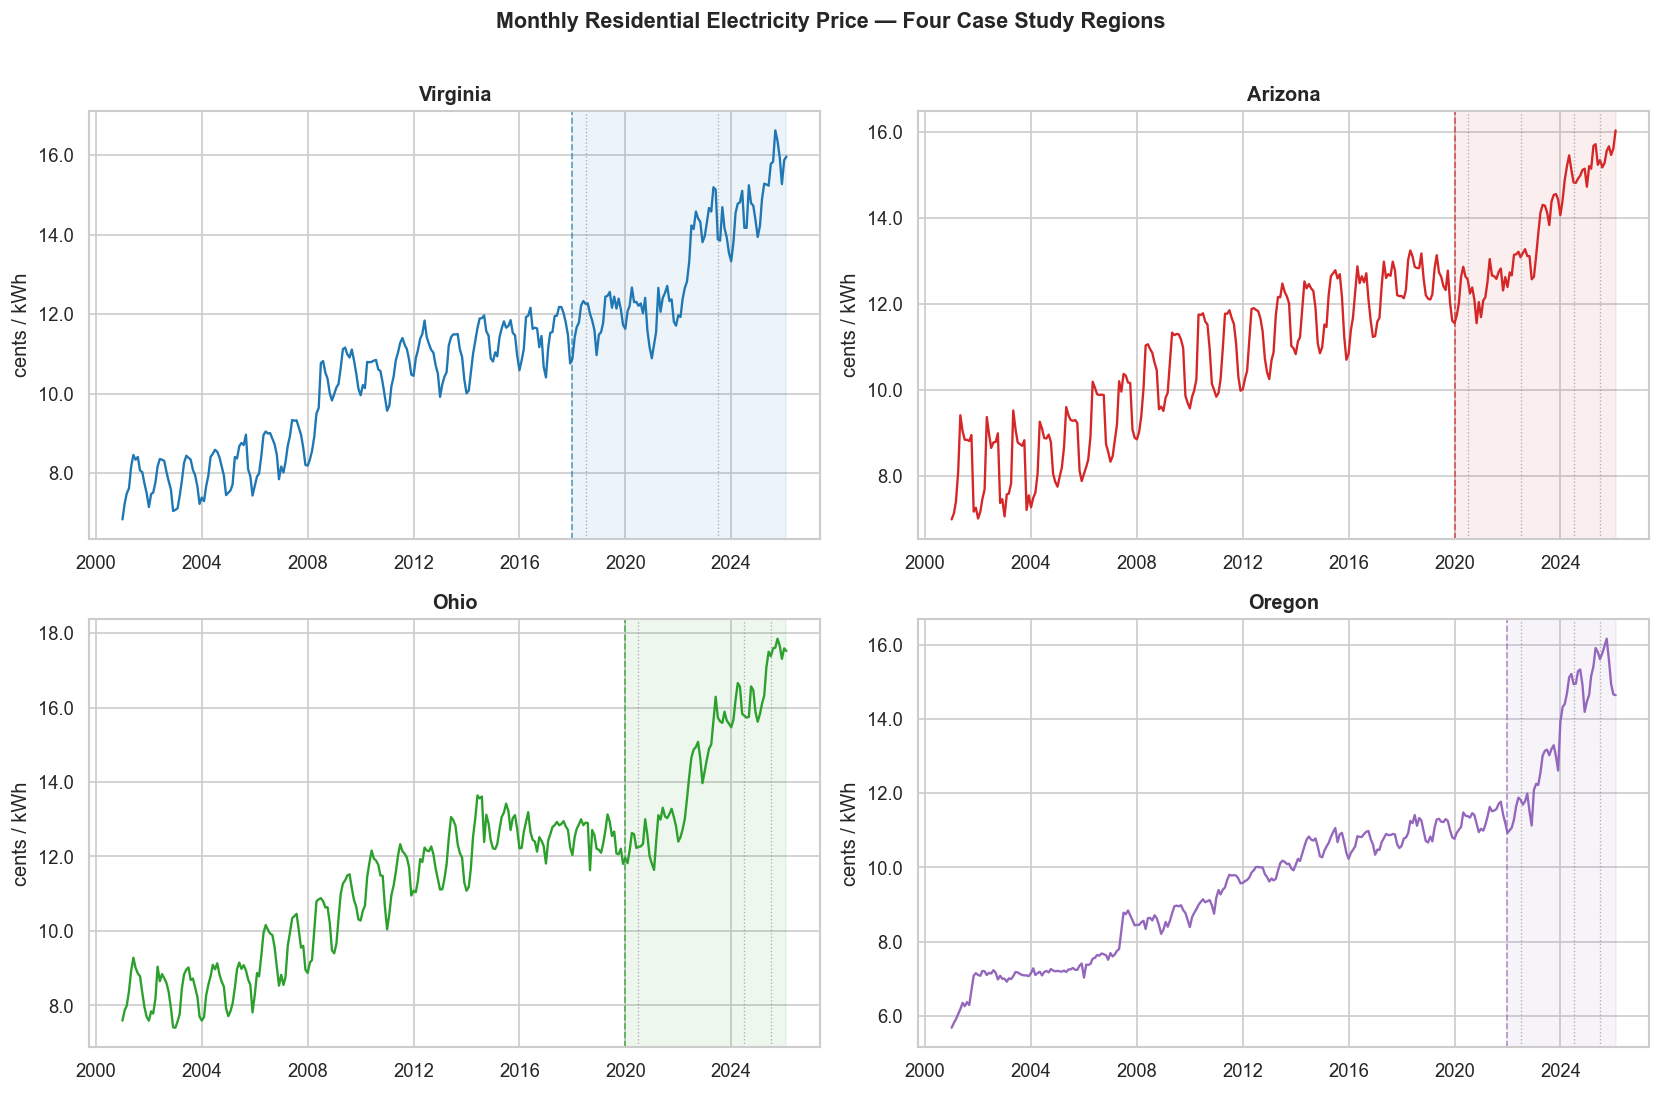

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, abbr in zip(axes, ['VA', 'AZ', 'OH', 'OR']):
    data = df_monthly[df_monthly['state_abbr'] == abbr]
    ax.plot(data['period'], data['res_price_cents_kwh'],
            color=COLORS[abbr], linewidth=1.4)

    boom_date = pd.Timestamp(f'{BOOM[abbr]}-01-01')
    ax.axvspan(boom_date, data['period'].max(), alpha=0.08, color=COLORS[abbr])
    ax.axvline(boom_date, color=COLORS[abbr], linestyle='--', linewidth=1, alpha=0.7)

    # Key event markers
    for _, ev in df_events[df_events['region'] == STATE_LABEL[abbr]].iterrows():
        ev_date = pd.Timestamp(f"{int(ev['year'])}-07-01")
        if data['period'].min() <= ev_date <= data['period'].max():
            ax.axvline(ev_date, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

    ax.set_title(STATE_LABEL[abbr], fontweight='bold')
    ax.set_ylabel('cents / kWh')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

fig.suptitle('Monthly Residential Electricity Price — Four Case Study Regions',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig1_monthly_trends.png', bbox_inches='tight')
plt.show()

### 2.2 Before / after comparison
Average annual price in the 5 years before vs. 5 years after each region's boom cutpoint.

In [31]:
records = []
for abbr, boom_yr in BOOM.items():
    data = df_ann[df_ann['state_abbr'] == abbr]
    before = data[(data['year'] >= boom_yr - 5) & (data['year'] <  boom_yr)]['annual_avg_cents_kwh'].mean()
    after  = data[(data['year'] >= boom_yr)     & (data['year'] <  boom_yr + 5)]['annual_avg_cents_kwh'].mean()
    records.append({
        'state': STATE_LABEL[abbr], 'state_abbr': abbr, 'boom_year': boom_yr,
        'avg_before_cents_kwh': round(before, 2),
        'avg_after_cents_kwh':  round(after,  2),
        'abs_change':           round(after - before, 2),
        'pct_change':           round((after - before) / before * 100, 1),
    })

df_ba = pd.DataFrame(records)
df_ba.to_csv(PROC_DIR / 'before_after_summary.csv', index=False)
df_ba

,state,state_abbr,boom_year,avg_before_cents_kwh,avg_after_cents_kwh,abs_change,pct_change
0,Virginia,VA,2018,11.29,12.27,0.98,8.7
1,Arizona,AZ,2020,12.29,13.31,1.02,8.3
2,Ohio,OH,2020,12.59,14.09,1.50,11.9
3,Oregon,OR,2022,11.08,13.83,2.75,24.9


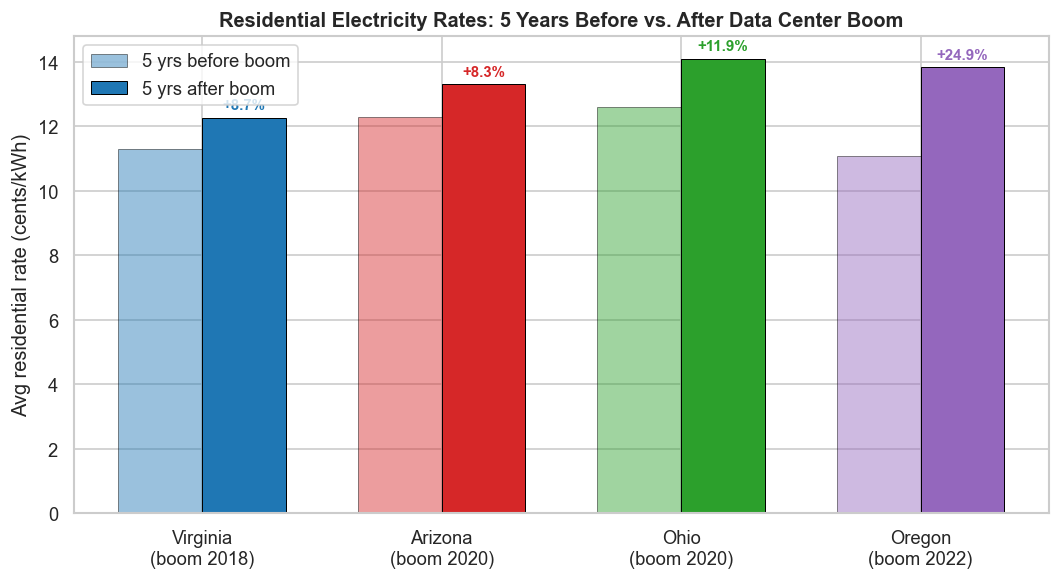

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(len(df_ba)), 0.35

ax.bar(x - w/2, df_ba['avg_before_cents_kwh'], w, label='5 yrs before boom',
       color=[COLORS[a] for a in df_ba['state_abbr']], alpha=0.45, edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, df_ba['avg_after_cents_kwh'],  w, label='5 yrs after boom',
       color=[COLORS[a] for a in df_ba['state_abbr']], alpha=1.0,  edgecolor='black', linewidth=0.6)

for i, row in df_ba.iterrows():
    ax.annotate(f"+{row['pct_change']}%",
                xy=(i + w/2, row['avg_after_cents_kwh']),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color=COLORS[row['state_abbr']])

ax.set_xticks(x)
ax.set_xticklabels([f"{r['state']}\n(boom {r['boom_year']})" for _, r in df_ba.iterrows()])
ax.set_ylabel('Avg residential rate (cents/kWh)')
ax.set_title('Residential Electricity Rates: 5 Years Before vs. After Data Center Boom', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig2_before_after.png', bbox_inches='tight')
plt.show()

### 2.3 Rate of price increase — before vs. after boom
Linear trend slope (cents/kWh per year) in each window. Positive acceleration = prices rising faster after the boom.

In [33]:
slope_records = []
for abbr, boom_yr in BOOM.items():
    data = df_ann[df_ann['state_abbr'] == abbr].dropna()
    for (y0, y1), lbl in [((boom_yr - 7, boom_yr), 'before'), ((boom_yr, boom_yr + 5), 'after')]:
        sub = data[(data['year'] >= y0) & (data['year'] < y1)]
        if len(sub) < 2:
            continue
        coef = np.polyfit(sub['year'], sub['annual_avg_cents_kwh'], 1)
        slope_records.append({'state': STATE_LABEL[abbr], 'state_abbr': abbr,
                               'period': lbl, 'slope_cents_per_year': round(coef[0], 3)})

df_slopes = pd.DataFrame(slope_records)
df_slopes.to_csv(PROC_DIR / 'rate_of_increase.csv', index=False)
df_slopes.pivot(index='state', columns='period', values='slope_cents_per_year')

period,after,before
state,,
Arizona,0.694,0.172
Ohio,1.005,0.031
Oregon,0.900,0.125
Virginia,0.314,0.137


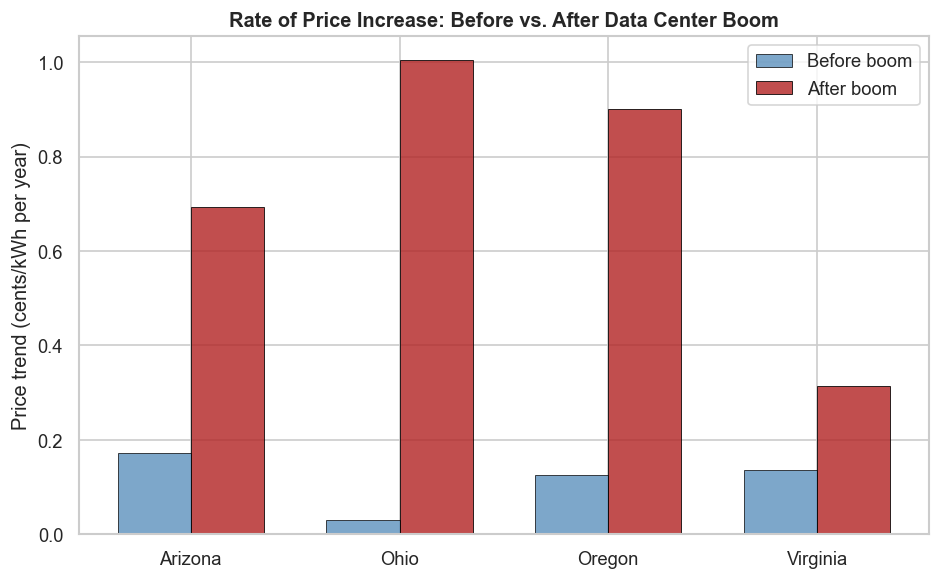

In [34]:
df_piv = df_slopes.pivot(index='state', columns='period', values='slope_cents_per_year').reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
x, w = np.arange(len(df_piv)), 0.35
ax.bar(x - w/2, df_piv['before'], w, label='Before boom', color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, df_piv['after'],  w, label='After boom',  color='firebrick', alpha=0.8, edgecolor='black', linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_piv['state'])
ax.set_ylabel('Price trend (cents/kWh per year)')
ax.set_title('Rate of Price Increase: Before vs. After Data Center Boom', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig3_rate_of_increase.png', bbox_inches='tight')
plt.show()

### 2.4 Indexed price comparison
All states indexed to 100 at their boom year, aligned on a relative time axis. Removes starting-price differences so the *pace* of increase can be compared directly.

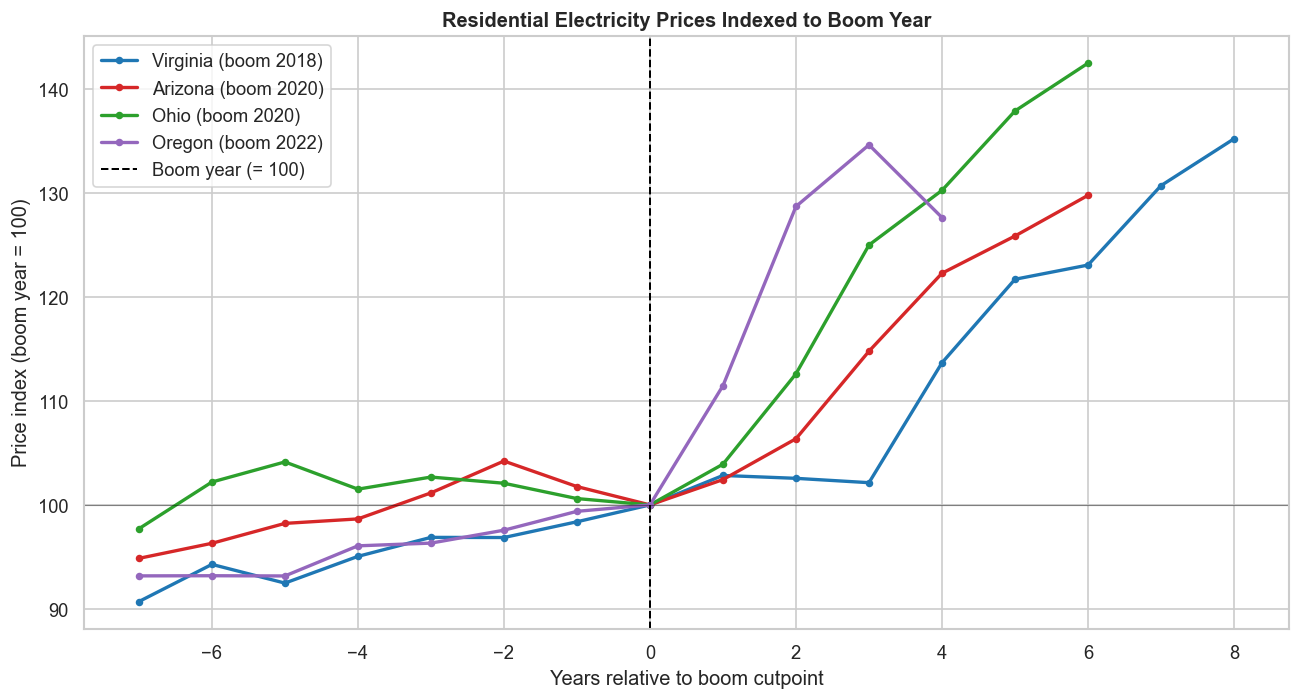

In [35]:
fig, ax = plt.subplots(figsize=(11, 6))

for abbr in ['VA', 'AZ', 'OH', 'OR']:
    boom_yr = BOOM[abbr]
    data = df_ann[df_ann['state_abbr'] == abbr].copy()
    data = data[data['year'] >= boom_yr - 7].sort_values('year')
    base = data[data['year'] == boom_yr]['annual_avg_cents_kwh'].values
    if len(base) == 0:
        continue
    data['indexed'] = data['annual_avg_cents_kwh'] / base[0] * 100
    ax.plot(data['year'] - boom_yr, data['indexed'],
            color=COLORS[abbr], linewidth=2, marker='o', markersize=3.5,
            label=f"{STATE_LABEL[abbr]} (boom {boom_yr})")

ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Boom year (= 100)')
ax.axhline(100, color='black', linewidth=0.7, alpha=0.4)
ax.set_xlabel('Years relative to boom cutpoint')
ax.set_ylabel('Price index (boom year = 100)')
ax.set_title('Residential Electricity Prices Indexed to Boom Year', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig4_indexed_comparison.png', bbox_inches='tight')
plt.show()

### 2.5 Year-over-year % change

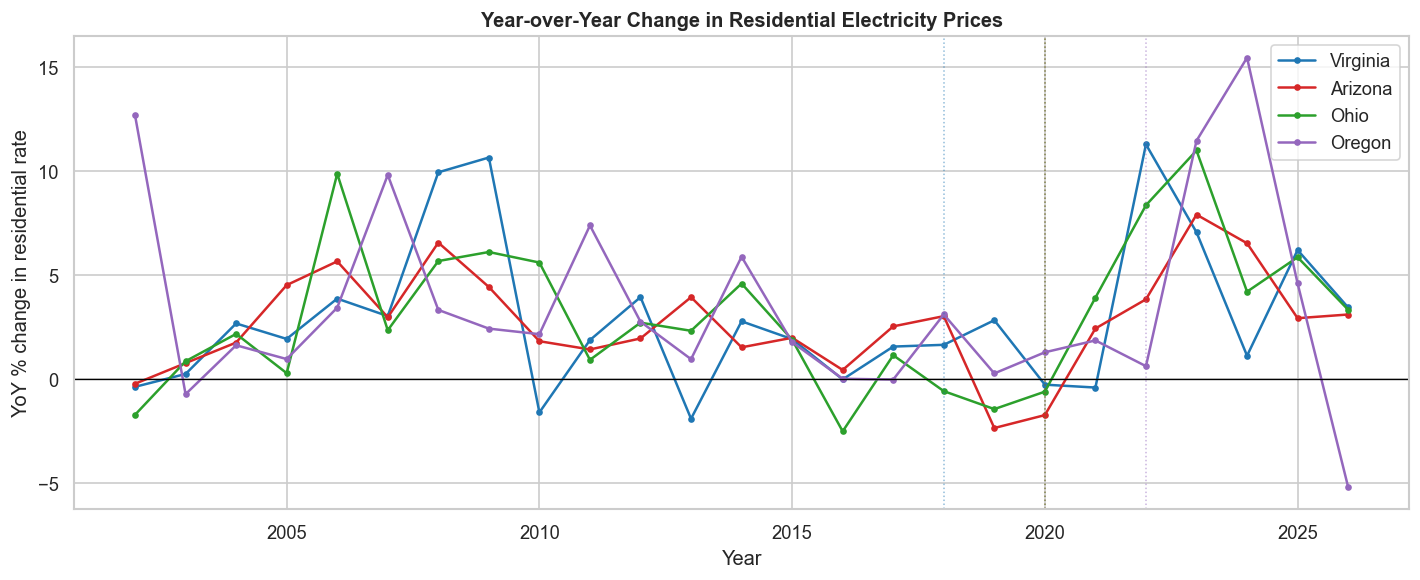

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))

for abbr in ['VA', 'AZ', 'OH', 'OR']:
    data = df_ann[df_ann['state_abbr'] == abbr].sort_values('year').copy()
    data['yoy_pct'] = data['annual_avg_cents_kwh'].pct_change() * 100
    ax.plot(data['year'], data['yoy_pct'], color=COLORS[abbr],
            linewidth=1.5, marker='o', markersize=3, label=STATE_LABEL[abbr])

for abbr, boom_yr in BOOM.items():
    ax.axvline(boom_yr, color=COLORS[abbr], linestyle=':', linewidth=0.9, alpha=0.5)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('YoY % change in residential rate')
ax.set_title('Year-over-Year Change in Residential Electricity Prices', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(PROC_DIR / 'fig5_yoy_change.png', bbox_inches='tight')
plt.show()

### 2.6 Summary table

In [37]:
df_summary = (
    df_ba
    .merge(df_slopes[df_slopes['period'] == 'before'][['state_abbr', 'slope_cents_per_year']]
           .rename(columns={'slope_cents_per_year': 'slope_before'}), on='state_abbr')
    .merge(df_slopes[df_slopes['period'] == 'after'][['state_abbr', 'slope_cents_per_year']]
           .rename(columns={'slope_cents_per_year': 'slope_after'}), on='state_abbr')
)
df_summary['slope_acceleration'] = (df_summary['slope_after'] - df_summary['slope_before']).round(3)
df_summary.to_csv(PROC_DIR / 'summary.csv', index=False)

df_summary[['state', 'boom_year', 'avg_before_cents_kwh', 'avg_after_cents_kwh',
            'pct_change', 'slope_before', 'slope_after', 'slope_acceleration']].rename(columns={
    'avg_before_cents_kwh': 'avg_before (c/kWh)',
    'avg_after_cents_kwh':  'avg_after (c/kWh)',
    'pct_change':           '% change',
    'slope_before':         'trend before (c/yr)',
    'slope_after':          'trend after (c/yr)',
    'slope_acceleration':   'acceleration (c/yr)',
})

,state,boom_year,avg_before (c/kWh),avg_after (c/kWh),% change,trend before (c/yr),trend after (c/yr),acceleration (c/yr)
0,Virginia,2018,11.29,12.27,8.7,0.137,0.314,0.177
1,Arizona,2020,12.29,13.31,8.3,0.172,0.694,0.522
2,Ohio,2020,12.59,14.09,11.9,0.031,1.005,0.974
3,Oregon,2022,11.08,13.83,24.9,0.125,0.900,0.775


In [38]:
import shutil
from pathlib import Path

VIZ_DIR = Path('../visualizations')
VIZ_DIR.mkdir(exist_ok=True)

prefix = 'electricity'
for png in sorted(PROC_DIR.glob('*.png')):
    dest = VIZ_DIR / f'electricity_{png.name}'
    shutil.copy2(png, dest)
    print(f'  → {dest.name}')
print(f'Exported {len(list(PROC_DIR.glob("*.png")))} figures to visualizations/')

  → electricity_fig1_monthly_trends.png
  → electricity_fig2_before_after.png
  → electricity_fig3_rate_of_increase.png
  → electricity_fig4_indexed_comparison.png
  → electricity_fig5_yoy_change.png
Exported 5 figures to visualizations/
